In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
import random

import wandb

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="23f3003691_team",
    # Set the wandb project where this run will be logged.
    project="23f3003691-t22026",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.02,
        "architecture": "CNN",
        "dataset": "CIFAR-100",
        "epochs": 10,
    },
)

# Simulate training.
epochs = 10
offset = random.random() / 5
for epoch in range(2, epochs):
    acc = 1 - 2**-epoch - random.random() / epoch - offset
    loss = 2**-epoch + random.random() / epoch + offset

    # Log metrics to wandb.
    run.log({"acc": acc, "loss": loss})

# Finish the run and upload any remaining data.
run.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sasivaibhav (23f3003691_team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


acc,▂▁▇▆█▆██
loss,█▅▃▂▃▁▂▁
acc,0.78033
loss,0.20751


In [3]:
import os
import pandas as pd
import numpy as np

DATA_DIR = "/kaggle/input/competitions/smart-mcq-solver-challenge"
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

def generate_baseline_submission():
    print("--- Loading Datasets ---")
    train_df = pd.read_csv(TRAIN_PATH)
    test_df = pd.read_csv(TEST_PATH)
    sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
    
    print(f"Train shape: {train_df.shape}")
    print(f"Test shape: {test_df.shape}")
    
    # 1. Explicitly define the column names to handle case mismatches
    test_id_col = 'id'                     # Lowercase in test.csv
    sub_id_col = sample_sub.columns[0]     # Uppercase 'ID' in sample_submission.csv
    pred_col = sample_sub.columns[1]       # 'Prediction'
    
    # 2. Create a basic dummy prediction
    dummy_prediction = "A B C"
    
    print(f"Generating dummy predictions ('{dummy_prediction}') for all rows...")
    
    # 3. Construct submission dataframe mapping test 'id' to submission 'ID'
    submission_df = pd.DataFrame({
        sub_id_col: test_df[test_id_col], 
        pred_col: [dummy_prediction] * len(test_df)
    })
    
    # 4. Save to the current working directory
    OUTPUT_PATH = "submission.csv"
    submission_df.to_csv(OUTPUT_PATH, index=False)
    
    print(f"\n--- Submission file successfully created at: {OUTPUT_PATH} ---")
    print(submission_df.head())

if __name__ == "__main__":
    generate_baseline_submission()

--- Loading Datasets ---
Train shape: (2000, 8)
Test shape: (500, 7)
Generating dummy predictions ('A B C') for all rows...

--- Submission file successfully created at: submission.csv ---
   ID Prediction
0   1      A B C
1   2      A B C
2   3      A B C
3   4      A B C
4   5      A B C


In [3]:
import pandas as pd
import numpy as np
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
print(train.shape)
print(test.shape)

train.head()

(2000, 8)
(500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [4]:
print(train.isnull().sum())
print(test.isnull().sum())

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64


In [5]:
print(train.duplicated().sum())

0


In [6]:
train['answer'].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

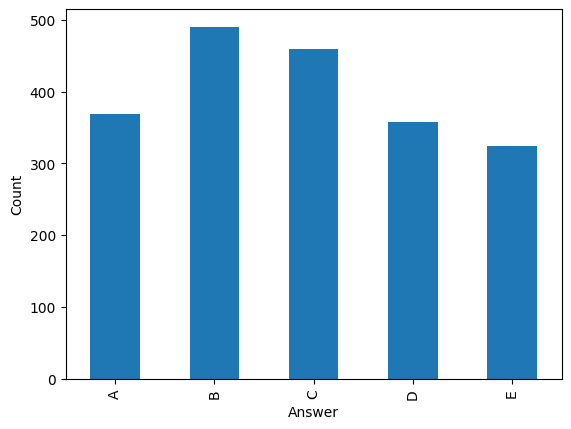

In [7]:
import matplotlib.pyplot as plt

train['answer'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Answer")
plt.ylabel("Count")
plt.show()

In [8]:
import re

def clean_text(text):
    text = str(text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text

text_columns = ["prompt", "A", "B", "C", "D", "E"]

for col in text_columns:
    train[col] = train[col].apply(clean_text)
    test[col] = test[col].apply(clean_text)

In [9]:
def combine_text(row):
    return (
        f"Question: {row['prompt']}\n"
        f"A. {row['A']}\n"
        f"B. {row['B']}\n"
        f"C. {row['C']}\n"
        f"D. {row['D']}\n"
        f"E. {row['E']}"
    )

train["text"] = train.apply(combine_text, axis=1)
test["text"] = test.apply(combine_text, axis=1)

In [13]:
label_map = {
    "A":0,
    "B":1,
    "C":2,
    "D":3,
    "E":4
}

train["label"] = train["answer"].map(label_map)

In [14]:
from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train["label"]
)

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
 8   text    2000 non-null   object
 9   label   2000 non-null   int64 
dtypes: int64(2), object(8)
memory usage: 156.4+ KB


In [19]:
train["prompt"].duplicated().sum()
train[train["prompt"].duplicated(keep=False)].sort_values("prompt")

,id,prompt,A,B,C,D,E,answer,text,label
605,606,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E,Question: Choose the correct answer: What are ...,4
456,457,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E,Question: Choose the correct answer: What are ...,4
439,440,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E,Question: Choose the correct answer: What are ...,4
1464,1465,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E,Question: Choose the correct answer: What are ...,4
42,43,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E,Question: Choose the correct answer: What are ...,4
...,...,...,...,...,...,...,...,...,...,...
1313,1314,Which of the following is correct? Which of th...,MOND is a concept that reduces the observed mi...,MOND is a framework that raises the discrepanc...,MOND is a concept that explains the missing ba...,MOND is a concept that reduces the discrepancy...,MOND is a framework that eliminates the observ...,D,Question: Which of the following is correct? W...,3
1649,1650,Which of the following is correct? Who propose...,Ilya Prigogine in 1979,Henri Atlan in 1972,Democritus and Lucretius in ancient times,None of the above.,René Descartes in 1637,B,Question: Which of the following is correct? W...,1
708,709,Which of the following is correct? Who propose...,Ilya Prigogine in 1979,Henri Atlan in 1972,Democritus and Lucretius in ancient times,None of the above.,René Descartes in 1637,B,Question: Which of the following is correct? W...,1
1623,1624,Which of the following is correct? Who was Gio...,A German philosopher who supported the Kepleri...,An English philosopher who supported the Ptole...,A French philosopher who supported the Aristot...,An Italian philosopher who supported the Coper...,A Spanish philosopher who supported the Galile...,D,Question: Which of the following is correct? W...,3


In [20]:
train["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

In [26]:
for col in ["A","B","C","D","E"]:

    train[col+"_words"] = train[col].apply(
        lambda x: len(str(x).split())
    )

train[
[
"A_words",
"B_words",
"C_words",
"D_words",
"E_words"
]
].mean()

A_words    26.1460
B_words    26.5160
C_words    26.5495
D_words    25.9995
E_words    26.1870
dtype: float64

In [27]:
train.nlargest(
    5,
    "prompt_words"
)[["prompt","answer"]]

,prompt,answer
1484,Select the most accurate option: What is one o...,C
1980,Identify the correct statement: What is one of...,C
574,Choose the correct answer: What is one of the ...,C
1164,Determine the correct option: What is one of t...,C
1611,Determine the correct option: What is one of t...,C


In [28]:
train.nsmallest(
    5,
    "prompt_words"
)[["prompt","answer"]]

,prompt,answer
479,What is emissivity?,C
1398,What is resistivity?,C
1510,What is organography?,B
34,What is a pycnometer?,D
319,What is a light-year?,B


In [29]:
print("Unique Prompts")

print(train["prompt"].nunique())

Unique Prompts
1758


In [30]:
all_text = " ".join(train["prompt"])

words = all_text.split()

print("Vocabulary Size:", len(set(words)))

Vocabulary Size: 938


In [31]:
sample = train.sample(1).iloc[0]

print(sample["prompt"])

print()

print("A:", sample["A"])

print("B:", sample["B"])

print("C:", sample["C"])

print("D:", sample["D"])

print("E:", sample["E"])

print()

print("Correct:", sample["answer"])

Pick the best possible answer: What is the definition of Atomristor? among the listed options.

A: Atomristor is a flexible memristive device comprising a MoOx/MoS2 heterostructure sandwiched between silver electrodes on a plastic foil.
B: Atomristor is a prominent memcapacitive effect observed in switches with memristive behavior.
C: Atomristor is defined as the electrical devices showing memristive behavior in atomically thin nanomaterials or atomic sheets.
D: Atomristor is a printing and solution-processing technology used to fabricate memristive devices.
E: Atomristor is a type of two-dimensional layered transition metal dichalcogenides (TMDs) used in the fabrication of memristive devices.

Correct: C


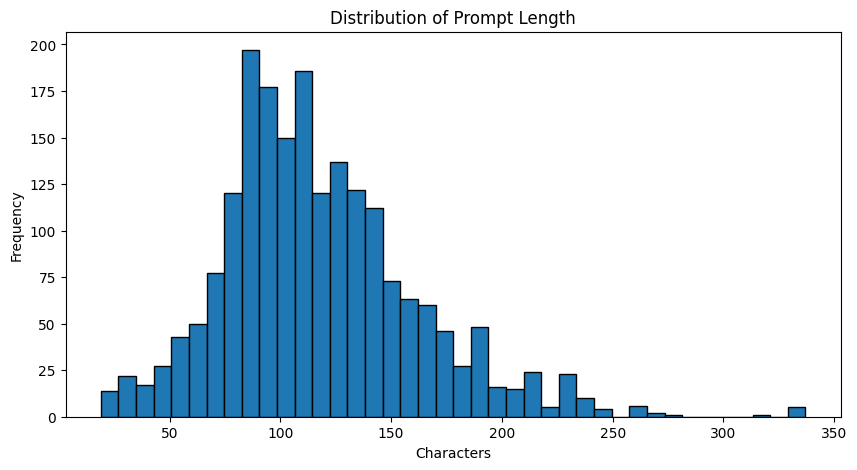

In [33]:
train['prompt_length'] = train['prompt'].str.len()

plt.figure(figsize=(10,5))

plt.hist(train['prompt_length'],
         bins=40,
         edgecolor='black')

plt.title("Distribution of Prompt Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

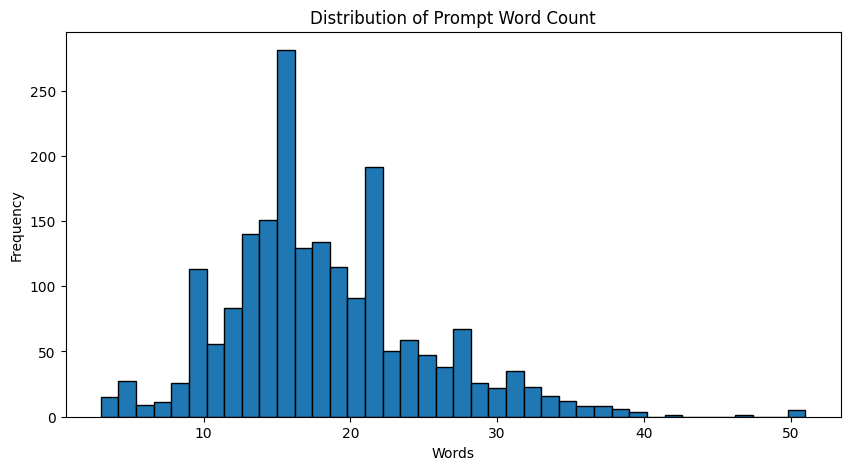

In [32]:
train['prompt_words'] = train['prompt'].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(10,5))

plt.hist(train['prompt_words'],
         bins=40,
         edgecolor='black')

plt.title("Distribution of Prompt Word Count")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

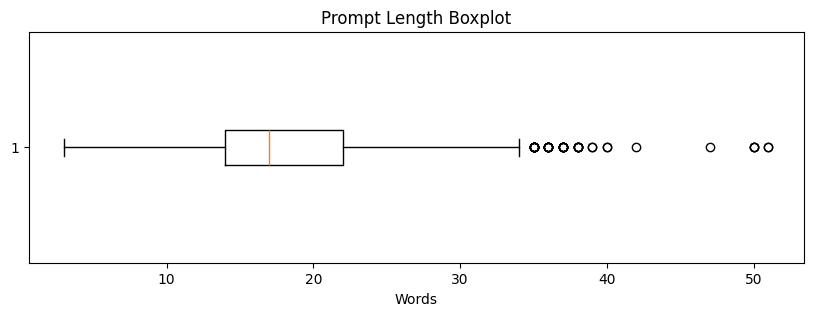

In [35]:
plt.figure(figsize=(10,3))

plt.boxplot(train['prompt_words'],
            vert=False)

plt.title("Prompt Length Boxplot")

plt.xlabel("Words")

plt.show()

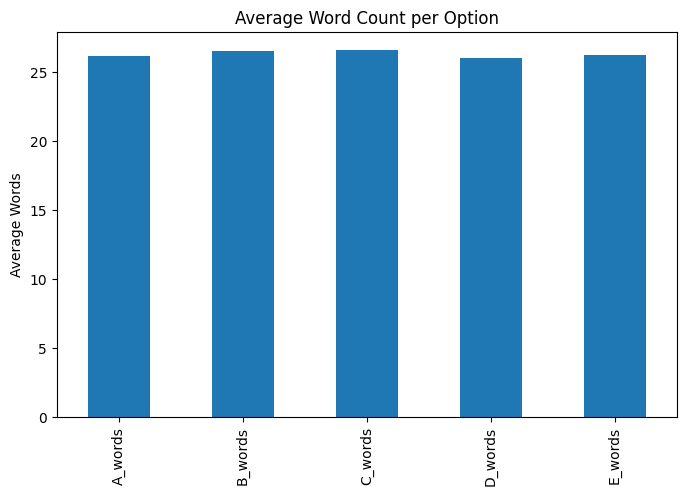

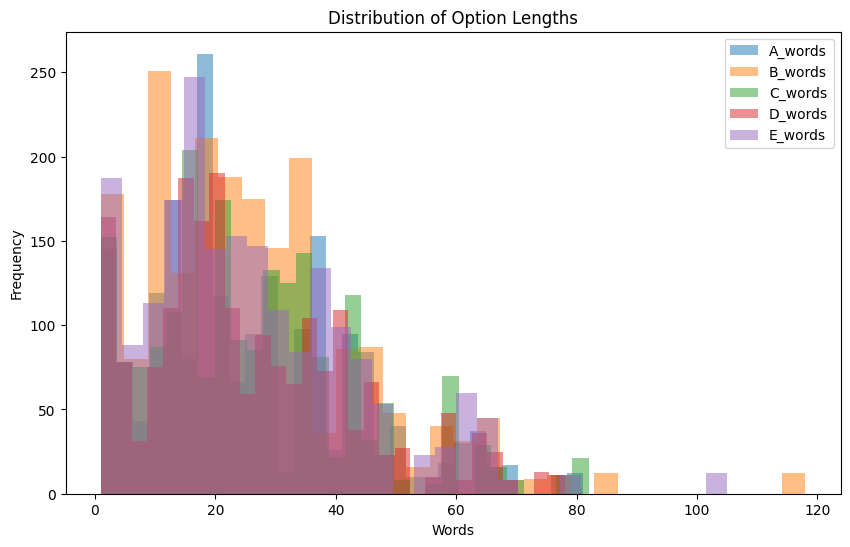

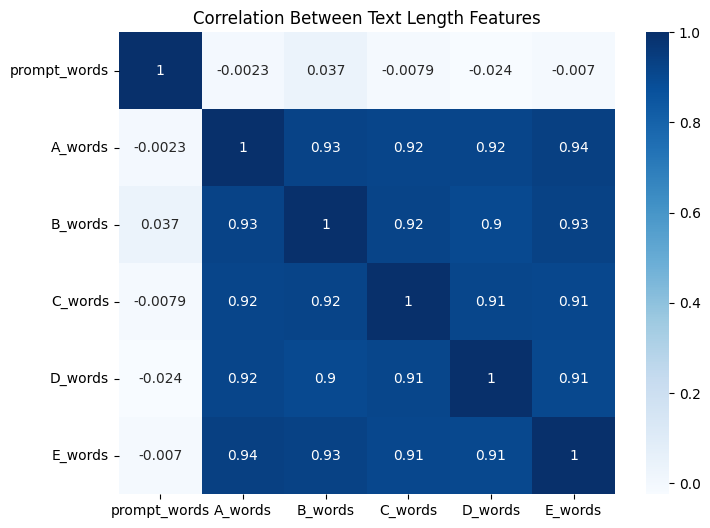

In [38]:
for col in ['A','B','C','D','E']:
    train[col+"_words"] = train[col].apply(
        lambda x: len(str(x).split())
    )

means = train[
[
'A_words',
'B_words',
'C_words',
'D_words',
'E_words'
]
].mean()

means.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Word Count per Option")

plt.ylabel("Average Words")

plt.show()
plt.figure(figsize=(10,6))

for col in ['A_words','B_words','C_words','D_words','E_words']:
    plt.hist(train[col],
             bins=30,
             alpha=0.5,
             label=col)

plt.legend()

plt.title("Distribution of Option Lengths")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()
numeric = train[
[
'prompt_words',
'A_words',
'B_words',
'C_words',
'D_words',
'E_words'
]
]

import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Between Text Length Features")

plt.show()

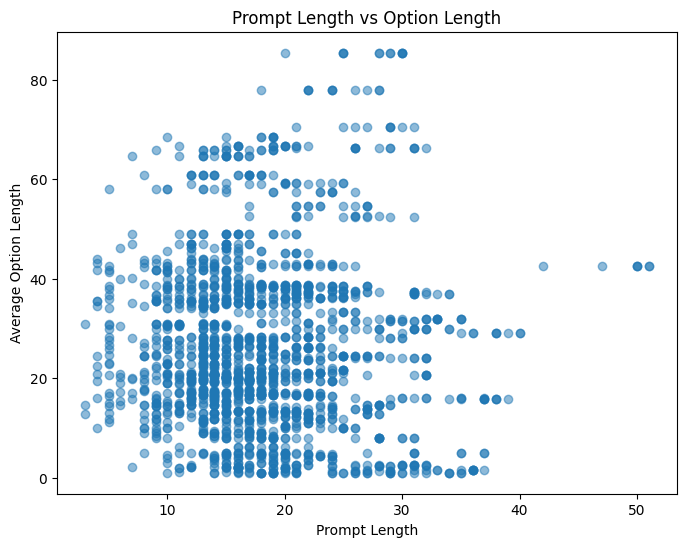

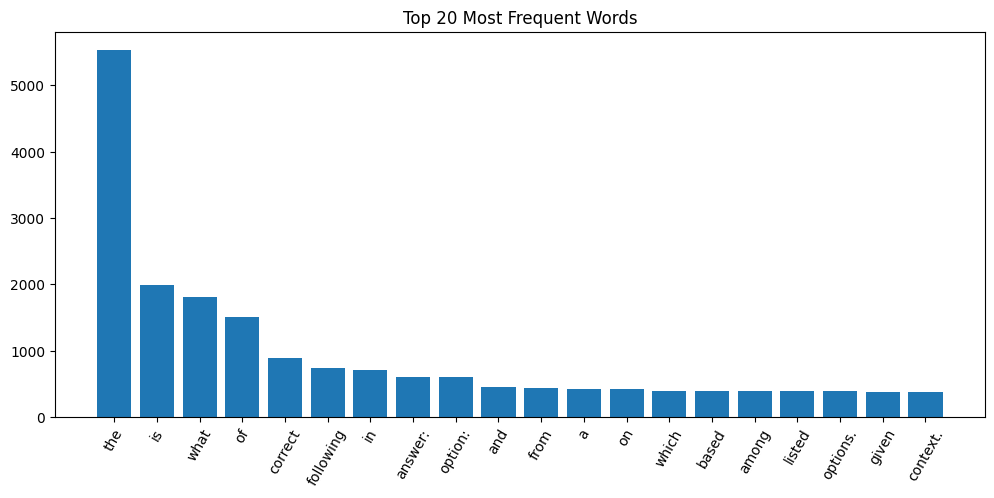

In [40]:
train['avg_option_length'] = train[
[
'A_words',
'B_words',
'C_words',
'D_words',
'E_words'
]
].mean(axis=1)

plt.figure(figsize=(8,6))

plt.scatter(
    train['prompt_words'],
    train['avg_option_length'],
    alpha=0.5
)

plt.xlabel("Prompt Length")

plt.ylabel("Average Option Length")

plt.title("Prompt Length vs Option Length")

plt.show()
from collections import Counter

text = " ".join(train['prompt'])

words = text.lower().split()

counter = Counter(words)

common = counter.most_common(20)

words = [x[0] for x in common]

counts = [x[1] for x in common]

plt.figure(figsize=(12,5))

plt.bar(words, counts)

plt.xticks(rotation=60)

plt.title("Top 20 Most Frequent Words")

plt.show()

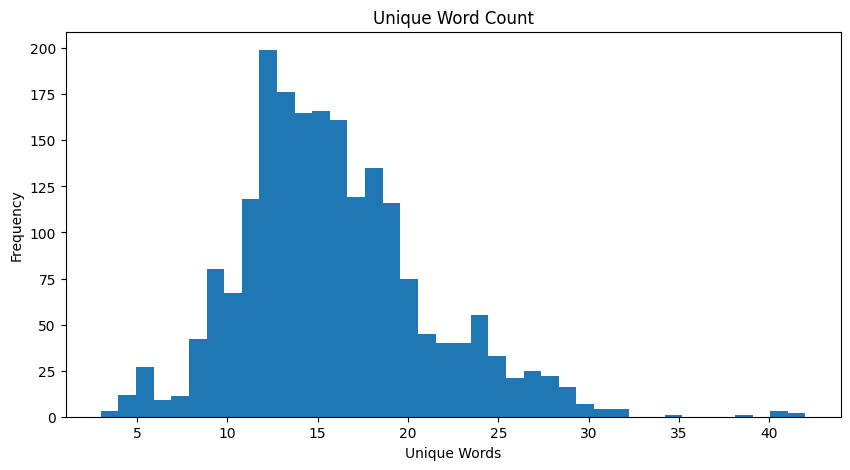

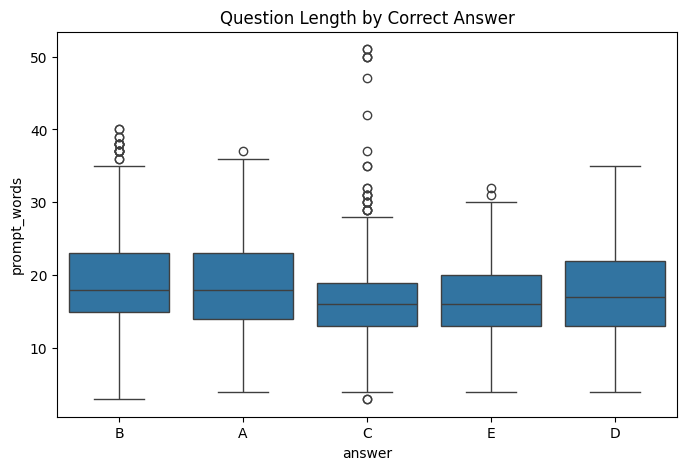

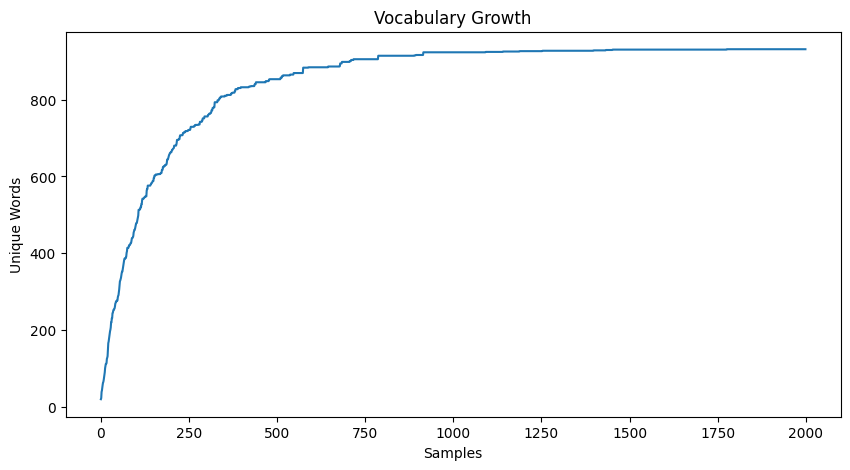

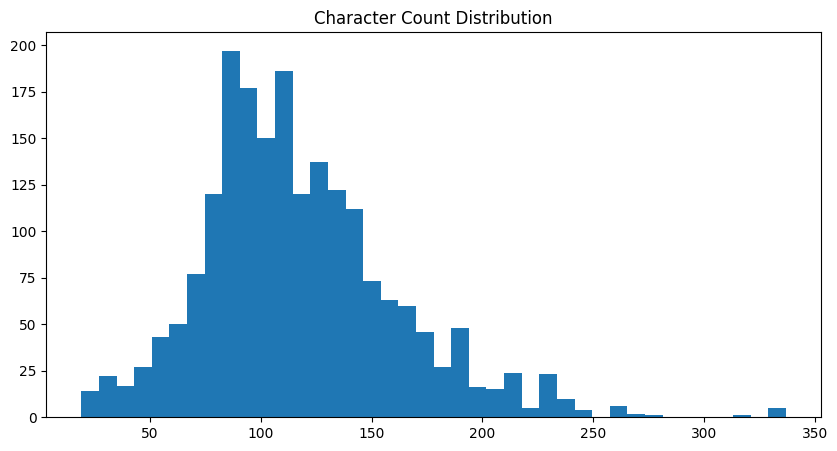

In [46]:
train["unique_words"] = train["prompt"].apply(
    lambda x: len(set(str(x).split()))
)

plt.figure(figsize=(10,5))

plt.hist(train["unique_words"],
         bins=40)

plt.title("Unique Word Count")

plt.xlabel("Unique Words")

plt.ylabel("Frequency")

plt.show()
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x="answer",
    y="prompt_words",
    data=train
)

plt.title("Question Length by Correct Answer")

plt.show()
vocab = set()

growth = []

for sentence in train['prompt']:
    vocab.update(sentence.lower().split())
    growth.append(len(vocab))

plt.figure(figsize=(10,5))

plt.plot(growth)

plt.title("Vocabulary Growth")

plt.xlabel("Samples")

plt.ylabel("Unique Words")

plt.show()
train["char_count"] = train["prompt"].str.len()

plt.figure(figsize=(10,5))

plt.hist(
    train["char_count"],
    bins=40
)

plt.title("Character Count Distribution")

plt.show()

In [48]:
def create_input(row):
    return (
        f"Question: {row['prompt']}\n"
        f"A: {row['A']}\n"
        f"B: {row['B']}\n"
        f"C: {row['C']}\n"
        f"D: {row['D']}\n"
        f"E: {row['E']}"
    )

train["input_text"] = train.apply(create_input, axis=1)
test["input_text"] = test.apply(create_input, axis=1)
label2id = {
    "A":0,
    "B":1,
    "C":2,
    "D":3,
    "E":4
}

id2label = {v:k for k,v in label2id.items()}

train["label"] = train["answer"].map(label2id)

In [49]:
from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train["label"]
)
train_df.to_csv("train_processed.csv", index=False)
valid_df.to_csv("valid_processed.csv", index=False)
test.to_csv("test_processed.csv", index=False)

In [53]:
train_df = train.copy()
test_df = test.copy()

In [55]:
import re

def clean_text(text):

    text = str(text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()


columns = [
    "prompt",
    "A",
    "B",
    "C",
    "D",
    "E"
]

for col in columns:

    train_df[col] = train_df[col].apply(clean_text)

    test_df[col] = test_df[col].apply(clean_text)

In [50]:
train_df[["input_text", "label"]].head()

,input_text,label
386,Question: Select the most accurate option: Wha...,2
1900,Question: Determine the correct option: What i...,4
1697,Question: Identify the correct statement: What...,4
714,Question: Determine the correct option: Which ...,3
1134,Question: Select the most accurate option: Wha...,1


In [56]:
train_df["input_text"] = train_df.apply(
    create_input,
    axis=1
)

test_df["input_text"] = test_df.apply(
    create_input,
    axis=1
)

In [57]:
print(train_df["input_text"].iloc[0])

Question: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
B: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
C: Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.
D: Martin Heidegger believes that the relationsh

In [58]:
#encoding labels
label2id = {
    "A":0,
    "B":1,
    "C":2,
    "D":3,
    "E":4
}

id2label = {v:k for k,v in label2id.items()}

train_df["label"] = train_df["answer"].map(label2id)

In [59]:
train_split, valid_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

In [60]:
print(train_split.shape)
print(valid_split.shape)

(1600, 21)
(400, 21)


In [8]:

train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

train_df = train.copy()
test_df = test.copy()